In [1]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 1: Import required libraries
# ============================================================

# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for machine learning preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ignore warnings to keep notebook output clean
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 2: Load cleaned dataset
# ============================================================

# Load the cleaned dataset from the correct cleaned data folder
df = pd.read_csv("../02_cleaned_data/Drishti_Clean_Data.csv")

# Show the dataset size
print("Dataset shape:", df.shape)

# Show first 5 rows
df.head()

Dataset shape: (3000, 40)


,Client_ID,Age,Gender,Country,City,Diet_Type,Goal_Type,Lead_Source,Referred_By,Health_Condition,...,Progress_Photos_Shared,Goal_Achieved,Returned_After_Drop,Weeks_Before_Return,Return_Trigger,Revenue_USD,Second_Round,Program_Duration_Days,Ever_Engaged,Was_Referred
0,C0001,24,Female,USA,Las Vegas,Vegetarian,Body Transformation,Other,NaN,Thyroid,...,Yes,Partial,NaN,0.0,NaN,300,No,100,True,False
1,C0002,30,Female,USA,Chicago,Non-Vegetarian,Body Transformation,Instagram,NaN,Thyroid,...,Yes,No,No,0.0,NaN,300,No,5,False,False
2,C0003,19,Female,USA,Houston,Non-Vegetarian,Weight Loss,TikTok,NaN,NaN,...,Yes,Partial,NaN,0.0,NaN,300,No,100,True,False
3,C0004,22,Female,Australia,Canberra,Non-Vegetarian,Weight Loss,TikTok,NaN,NaN,...,Yes,Yes,NaN,0.0,NaN,300,No,100,True,False
4,C0005,31,Male,USA,New York,Non-Vegetarian,Weight Loss,TikTok,NaN,NaN,...,No,No,Yes,11.0,Saw Other Clients Progress,300,No,4,True,False


In [6]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 3: Create churn target column
# ============================================================

# Create a new column called Churned
# Churned = 1 means the client did not successfully complete the program
# Churned = 0 means the client completed the program

df["Churned"] = df["Status"].apply(
    lambda x: 1 if x in ["Ghost", "Inactive", "Quit"] else 0
)

# Count how many clients churned and did not churn
churn_count = df["Churned"].value_counts()

# Calculate churn percentage
churn_percentage = df["Churned"].value_counts(normalize=True) * 100

print("Churn count:")
print(churn_count)

print("\nChurn percentage:")
print(churn_percentage.round(2))

Churn count:
Churned
0    2431
1     569
Name: count, dtype: int64

Churn percentage:
Churned
0    81.03
1    18.97
Name: proportion, dtype: float64


In [8]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 4: Select only first-week features
# ============================================================

# These are the only columns we are allowed to use for early churn prediction.
# They are known during intake or within the first week.
# We are NOT using future outcome columns like Goal_Achieved, Checkin_Rate_Pct, or Second_Round.

feature_columns = [
    "Age",
    "Gender",
    "Country",
    "Goal_Type",
    "Goal_Gap_kg",
    "Diet_Type",
    "Lead_Source",
    "Health_Condition",
    "Daily_Schedule",
    "Exercise_History",
    "Motivation_Level_Start",
    "Payment_Speed_Days",
    "Days_To_First_Engagement",
    "Ever_Engaged",
    "Was_Referred"
]

# Create X as the input features
X = df[feature_columns]

# Create y as the target we want to predict
y = df["Churned"]

# Show selected columns and shapes
print("Selected feature columns:")
print(X.columns.tolist())

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)

Selected feature columns:
['Age', 'Gender', 'Country', 'Goal_Type', 'Goal_Gap_kg', 'Diet_Type', 'Lead_Source', 'Health_Condition', 'Daily_Schedule', 'Exercise_History', 'Motivation_Level_Start', 'Payment_Speed_Days', 'Days_To_First_Engagement', 'Ever_Engaged', 'Was_Referred']

Feature dataset shape: (3000, 15)
Target shape: (3000,)


In [9]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 5: Check missing values in selected features
# ============================================================

# Check missing values in the selected model features
missing_values = X.isnull().sum()

# Show only columns that have missing values
missing_values = missing_values[missing_values > 0]

print("Missing values in selected features:")
print(missing_values)

# If no missing values exist, print a success message
if missing_values.empty:
    print("\nSuccess: There are no missing values in the selected model features.")

Missing values in selected features:
Health_Condition    1931
dtype: int64


In [10]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Fix Step 5A: Fill missing Health_Condition values
# ============================================================

# Fill missing Health_Condition values with "No Condition"
# This means the client did not report any specific health condition
df["Health_Condition"] = df["Health_Condition"].fillna("No Condition")

# Recreate X after fixing Health_Condition
X = df[feature_columns]

# Check missing values again
missing_values = X.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Missing values after fixing Health_Condition:")
print(missing_values)

if missing_values.empty:
    print("\nSuccess: There are no missing values in the selected model features.")

Missing values after fixing Health_Condition:
Series([], dtype: int64)

Success: There are no missing values in the selected model features.


In [11]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 6: Separate numeric and categorical features
# ============================================================

# Numeric columns contain number values
numeric_features = [
    "Age",
    "Goal_Gap_kg",
    "Payment_Speed_Days",
    "Days_To_First_Engagement"
]

# Categorical columns contain text/category values
categorical_features = [
    "Gender",
    "Country",
    "Goal_Type",
    "Diet_Type",
    "Lead_Source",
    "Health_Condition",
    "Daily_Schedule",
    "Exercise_History",
    "Motivation_Level_Start",
    "Ever_Engaged",
    "Was_Referred"
]

# Print both groups to confirm
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Age', 'Goal_Gap_kg', 'Payment_Speed_Days', 'Days_To_First_Engagement']

Categorical features:
['Gender', 'Country', 'Goal_Type', 'Diet_Type', 'Lead_Source', 'Health_Condition', 'Daily_Schedule', 'Exercise_History', 'Motivation_Level_Start', 'Ever_Engaged', 'Was_Referred']

Number of numeric features: 4
Number of categorical features: 11


In [12]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 7: Create preprocessing pipeline
# ============================================================

# Create scaler for numeric features
# This makes numeric columns easier for models to understand fairly
numeric_transformer = StandardScaler()

# Create encoder for categorical features
# This converts text categories into numeric columns
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine numeric scaling and categorical encoding into one preprocessing object
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [13]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 8: Create 80/20 stratified train-test split
# ============================================================

# Split the data into training and testing sets
# 80% of the data will be used to train the model
# 20% of the data will be used to test the model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print the size of each split
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Check churn distribution in training and testing sets
print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training feature shape: (2400, 15)
Testing feature shape: (600, 15)

Training target shape: (2400,)
Testing target shape: (600,)

Training churn distribution:
Churned
0    81.04
1    18.96
Name: proportion, dtype: float64

Testing churn distribution:
Churned
0    81.0
1    19.0
Name: proportion, dtype: float64


In [14]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 9: Apply preprocessing to training and testing data
# ============================================================

# Fit the preprocessor only on the training data
# This teaches the preprocessor how to scale and encode based on training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the testing data using the same rules learned from the training data
X_test_processed = preprocessor.transform(X_test)

# Print the new processed shapes
print("Processed training feature shape:", X_train_processed.shape)
print("Processed testing feature shape:", X_test_processed.shape)

Processed training feature shape: (2400, 44)
Processed testing feature shape: (600, 44)


In [16]:
%pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
# Test if SMOTE is now available
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [18]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 10: Apply SMOTE to training data
# ============================================================

# Create SMOTE object
# random_state makes the result repeatable
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
# This balances churned and non-churned clients in the training set
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

# Check class distribution before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Check class distribution after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Print training data shape before and after SMOTE
print("\nOriginal training shape:", X_train_processed.shape)
print("SMOTE training shape:", X_train_smote.shape)

Before SMOTE:
Churned
0    1945
1     455
Name: count, dtype: int64

After SMOTE:
Churned
0    1945
1    1945
Name: count, dtype: int64

Original training shape: (2400, 44)
SMOTE training shape: (3890, 44)


In [19]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 11: Train Model 1 - Logistic Regression
# ============================================================

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter is increased so the model has enough time to learn properly
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the SMOTE-balanced training data
log_reg_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [20]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 12: Evaluate Logistic Regression model
# ============================================================

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Make predictions on the untouched test data
log_reg_pred = log_reg_model.predict(X_test_processed)

# Get predicted probabilities for churn class
log_reg_prob = log_reg_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
log_reg_precision = precision_score(y_test, log_reg_pred)
log_reg_recall = recall_score(y_test, log_reg_pred)
log_reg_f1 = f1_score(y_test, log_reg_pred)
log_reg_auc = roc_auc_score(y_test, log_reg_prob)

# Print model performance
print("Logistic Regression Model Performance:")
print("--------------------------------------")
print("Accuracy:", round(log_reg_accuracy, 4))
print("Precision:", round(log_reg_precision, 4))
print("Recall:", round(log_reg_recall, 4))
print("F1 Score:", round(log_reg_f1, 4))
print("AUC-ROC:", round(log_reg_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, log_reg_pred))

Logistic Regression Model Performance:
--------------------------------------
Accuracy: 0.7267
Precision: 0.3626
Recall: 0.5789
F1 Score: 0.4459
AUC-ROC: 0.7313

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82       486
           1       0.36      0.58      0.45       114

    accuracy                           0.73       600
   macro avg       0.62      0.67      0.63       600
weighted avg       0.79      0.73      0.75       600



In [21]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 13: Train Model 2 - Random Forest
# ============================================================

# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
# n_estimators = number of decision trees
# random_state makes results repeatable
# class_weight helps the model pay attention to churned clients
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=8
)

# Train the model using the SMOTE-balanced training data
rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [22]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 14: Evaluate Random Forest model
# ============================================================

# Make predictions on the untouched test data
rf_pred = rf_model.predict(X_test_processed)

# Get predicted probabilities for churn class
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

# Print model performance
print("Random Forest Model Performance:")
print("--------------------------------")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("AUC-ROC:", round(rf_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Model Performance:
--------------------------------
Accuracy: 0.8433
Precision: 0.6316
Recall: 0.4211
F1 Score: 0.5053
AUC-ROC: 0.8003

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       486
           1       0.63      0.42      0.51       114

    accuracy                           0.84       600
   macro avg       0.75      0.68      0.71       600
weighted avg       0.83      0.84      0.83       600



In [25]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 15A: Test XGBoost import after installing libomp
# ============================================================

# Upgrade/install XGBoost inside the current Jupyter environment
%pip install --upgrade xgboost

# Import XGBoost model
from xgboost import XGBClassifier

print("XGBoost imported successfully.")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
XGBoost imported successfully.


In [26]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 15: Train Model 3 - XGBoost
# ============================================================

# Import XGBoost classifier
from xgboost import XGBClassifier

# Create the XGBoost model
# XGBoost is a powerful boosting model that learns from previous mistakes
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train the model using the SMOTE-balanced training data
xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [27]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 16: Evaluate XGBoost model
# ============================================================

# Make predictions on the untouched test data
xgb_pred = xgb_model.predict(X_test_processed)

# Get predicted probabilities for churn class
xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

# Print model performance
print("XGBoost Model Performance:")
print("--------------------------")
print("Accuracy:", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))
print("F1 Score:", round(xgb_f1, 4))
print("AUC-ROC:", round(xgb_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Model Performance:
--------------------------
Accuracy: 0.8517
Precision: 0.7049
Recall: 0.3772
F1 Score: 0.4914
AUC-ROC: 0.7983

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       486
           1       0.70      0.38      0.49       114

    accuracy                           0.85       600
   macro avg       0.79      0.67      0.70       600
weighted avg       0.84      0.85      0.83       600



In [28]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 17: Compare all three churn models
# ============================================================

# Create a comparison table for all models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_reg_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        log_reg_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        log_reg_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        log_reg_f1,
        rf_f1,
        xgb_f1
    ],
    "AUC-ROC": [
        log_reg_auc,
        rf_auc,
        xgb_auc
    ]
})

# Round the numbers for easier reading
model_comparison_rounded = model_comparison.copy()

numeric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
model_comparison_rounded[numeric_cols] = model_comparison_rounded[numeric_cols].round(4)

# Sort by Recall first because early churn detection cares most about catching at-risk clients
model_comparison_rounded = model_comparison_rounded.sort_values(
    by="Recall",
    ascending=False
)

print("Model Comparison Table:")
display(model_comparison_rounded)

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.7267,0.3626,0.5789,0.4459,0.7313
1,Random Forest,0.8433,0.6316,0.4211,0.5053,0.8003
2,XGBoost,0.8517,0.7049,0.3772,0.4914,0.7983


In [29]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 18: Choose best model for business use case
# ============================================================

# Choose the model with the highest recall
# Recall matters most because we want to catch as many at-risk clients as possible

best_model_name = "Logistic Regression"
best_model = log_reg_model
best_model_recall = log_reg_recall
best_model_auc = log_reg_auc

print("Best model selected:", best_model_name)
print("Reason: Highest recall among the three models")
print("Recall:", round(best_model_recall, 4))
print("AUC-ROC:", round(best_model_auc, 4))

Best model selected: Logistic Regression
Reason: Highest recall among the three models
Recall: 0.5789
AUC-ROC: 0.7313


In [30]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 19: Get feature names after preprocessing
# ============================================================

# Get numeric feature names
numeric_feature_names = numeric_features

# Get categorical feature names created by one-hot encoding
categorical_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

# Combine numeric and encoded categorical feature names
processed_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

# Check total number of processed features
print("Total processed feature names:", len(processed_feature_names))

# Show first 20 feature names
print("\nFirst 20 processed feature names:")
print(processed_feature_names[:20])

Total processed feature names: 44

First 20 processed feature names:
['Age', 'Goal_Gap_kg', 'Payment_Speed_Days', 'Days_To_First_Engagement', 'Gender_Female', 'Gender_Male', 'Country_Australia', 'Country_Canada', 'Country_Nepal', 'Country_Other', 'Country_UAE', 'Country_USA', 'Goal_Type_Body Transformation', 'Goal_Type_Weight Gain', 'Goal_Type_Weight Loss', 'Diet_Type_Eggetarian', 'Diet_Type_Non-Vegetarian', 'Diet_Type_Vegan', 'Diet_Type_Vegetarian', 'Lead_Source_Instagram']


In [31]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 20: Identify top churn signals from Logistic Regression
# ============================================================

# Get Logistic Regression coefficients
# These coefficients show how each feature is connected to churn risk
log_reg_coefficients = best_model.coef_[0]

# Create a dataframe with feature names and coefficients
feature_importance_lr = pd.DataFrame({
    "Feature": processed_feature_names,
    "Coefficient": log_reg_coefficients
})

# Add absolute coefficient value to measure strength of impact
feature_importance_lr["Absolute_Impact"] = feature_importance_lr["Coefficient"].abs()

# Sort by strongest impact
feature_importance_lr = feature_importance_lr.sort_values(
    by="Absolute_Impact",
    ascending=False
)

# Show top 10 strongest churn signals
top_10_churn_signals = feature_importance_lr.head(10)

print("Top 10 churn signals from Logistic Regression:")
display(top_10_churn_signals)

Top 10 churn signals from Logistic Regression:


,Feature,Coefficient,Absolute_Impact
3,Days_To_First_Engagement,4.273048,4.273048
32,Daily_Schedule_Shift Work,1.300557,1.300557
38,Motivation_Level_Start_Low,0.869349,0.869349
30,Daily_Schedule_Flexible,-0.789139,0.789139
31,Daily_Schedule_Homemaker,-0.540050,0.540050
27,Health_Condition_PCOS,0.487704,0.487704
39,Motivation_Level_Start_Medium,-0.484699,0.484699
28,Health_Condition_Thyroid,-0.441899,0.441899
35,Exercise_History_Occasional,0.377621,0.377621
25,Health_Condition_No Condition,0.350792,0.350792


In [32]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 21: State top 3 churn signals in business language
# ============================================================

# Get the top 3 strongest churn signals from the model
top_3_churn_signals = top_10_churn_signals.head(3)

print("The top 3 signals that a client will churn are:")
print("1. Delayed first engagement after starting the program")
print("2. Client has a shift work schedule")
print("3. Client starts with low motivation level")

print("\nTop 3 model features:")
display(top_3_churn_signals)

The top 3 signals that a client will churn are:
1. Delayed first engagement after starting the program
2. Client has a shift work schedule
3. Client starts with low motivation level

Top 3 model features:


,Feature,Coefficient,Absolute_Impact
3,Days_To_First_Engagement,4.273048,4.273048
32,Daily_Schedule_Shift Work,1.300557,1.300557
38,Motivation_Level_Start_Low,0.869349,0.869349


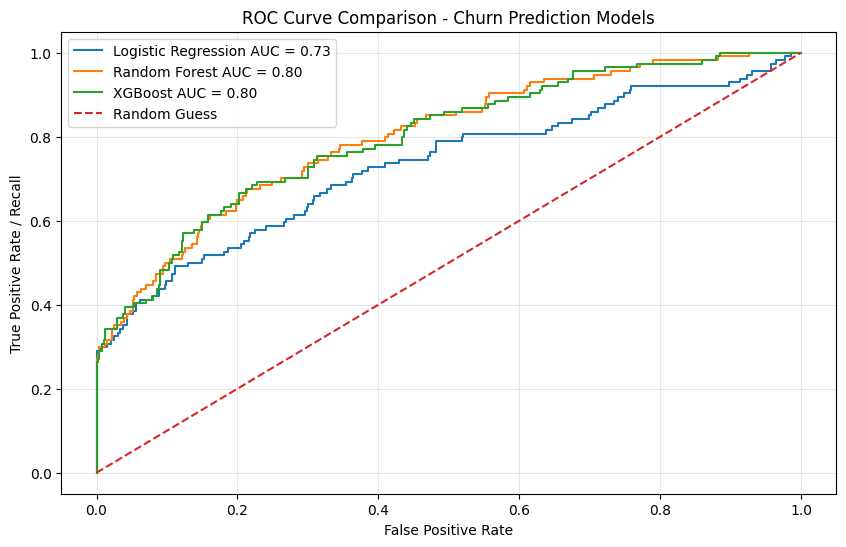

In [33]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 22: Visualize ROC curves for all three models
# ============================================================

# Import ROC curve function
from sklearn.metrics import roc_curve

# Calculate ROC curve values for Logistic Regression
log_reg_fpr, log_reg_tpr, _ = roc_curve(y_test, log_reg_prob)

# Calculate ROC curve values for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# Calculate ROC curve values for XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Create the ROC curve chart
plt.figure(figsize=(10, 6))

plt.plot(
    log_reg_fpr,
    log_reg_tpr,
    label=f"Logistic Regression AUC = {log_reg_auc:.2f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {rf_auc:.2f}"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost AUC = {xgb_auc:.2f}"
)

# Add diagonal baseline line
# This represents random guessing
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

# Add chart title and labels
plt.title("ROC Curve Comparison - Churn Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Show chart
plt.show()

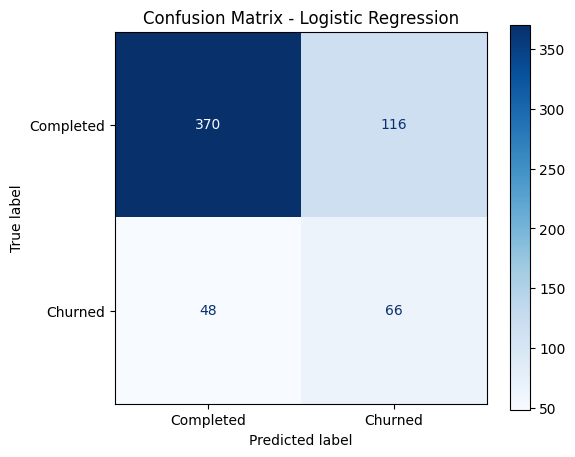

Confusion Matrix Values:
[[370 116]
 [ 48  66]]


In [34]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 23: Confusion matrix for selected model
# ============================================================

# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix for Logistic Regression
log_reg_cm = confusion_matrix(y_test, log_reg_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=log_reg_cm,
    display_labels=["Completed", "Churned"]
)

# Create chart
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")

# Add title
plt.title("Confusion Matrix - Logistic Regression")

# Show chart
plt.show()

# Print raw confusion matrix values
print("Confusion Matrix Values:")
print(log_reg_cm)

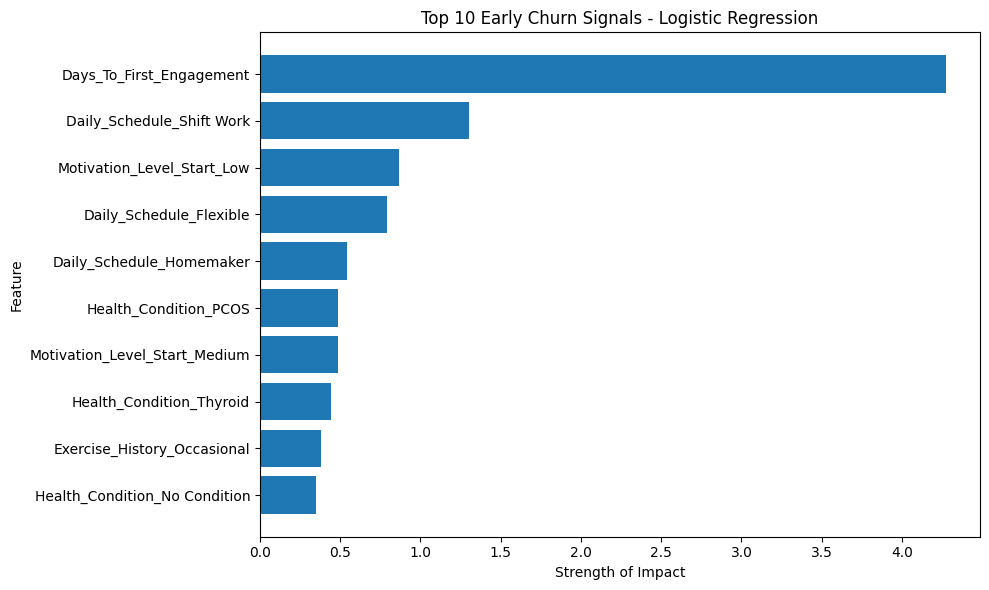

In [35]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 24: Create feature importance chart for top 10 churn signals
# ============================================================

# Create a copy of top 10 churn signals for plotting
top_10_plot = top_10_churn_signals.copy()

# Sort values so the strongest signal appears at the top of the chart
top_10_plot = top_10_plot.sort_values(by="Absolute_Impact", ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_plot["Feature"],
    top_10_plot["Absolute_Impact"]
)

# Add chart title and labels
plt.title("Top 10 Early Churn Signals - Logistic Regression")
plt.xlabel("Strength of Impact")
plt.ylabel("Feature")

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

In [36]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 25: Build new client risk-checking function
# ============================================================

def check_new_client_risk(client_info: dict) -> dict:
    """
    Drishti runs this for every new client after intake call.
    
    Input:
    client_info = dictionary with the same first-week feature names used by the model
    
    Output:
    risk level, churn probability, and one action to take
    
    Returns:
    {
        'risk': 'HIGH 🔴' / 'MEDIUM 🟡' / 'LOW 🟢',
        'probability': float,
        'action': 'specific thing Drishti should do right now'
    }
    """
    
    # Convert the client dictionary into a one-row dataframe
    new_client_df = pd.DataFrame([client_info])
    
    # Apply the same preprocessing used during model training
    new_client_processed = preprocessor.transform(new_client_df)
    
    # Predict churn probability using the selected best model
    churn_probability = best_model.predict_proba(new_client_processed)[0][1]
    
    # Create risk level and action based on probability
    if churn_probability >= 0.60:
        risk = "HIGH 🔴"
        action = (
            "Send a personal voice note today, ask what feels difficult, "
            "and schedule a quick accountability check-in within 24 hours."
        )
    elif churn_probability >= 0.35:
        risk = "MEDIUM 🟡"
        action = (
            "Send a supportive check-in message, remind the client of their first small goal, "
            "and ask them to confirm tomorrow's meal/check-in plan."
        )
    else:
        risk = "LOW 🟢"
        action = (
            "Continue normal follow-up and reinforce the client's early progress."
        )
    
    # Return result as a dictionary
    return {
        "risk": risk,
        "probability": round(float(churn_probability), 4),
        "action": action
    }

print("New client risk-checking function created successfully.")

New client risk-checking function created successfully.


In [37]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 26: Test risk-checking function with 3 example clients
# ============================================================

# Example 1: High-risk client
high_risk_client = {
    "Age": 29,
    "Gender": "Female",
    "Country": "USA",
    "Goal_Type": "Weight Loss",
    "Goal_Gap_kg": 18,
    "Diet_Type": "Non-Vegetarian",
    "Lead_Source": "TikTok",
    "Health_Condition": "PCOS",
    "Daily_Schedule": "Shift Work",
    "Exercise_History": "Occasional",
    "Motivation_Level_Start": "Low",
    "Payment_Speed_Days": 10,
    "Days_To_First_Engagement": 7,
    "Ever_Engaged": "Yes",
    "Was_Referred": "No"
}

# Example 2: Medium-risk client
medium_risk_client = {
    "Age": 34,
    "Gender": "Female",
    "Country": "Australia",
    "Goal_Type": "Body Transformation",
    "Goal_Gap_kg": 12,
    "Diet_Type": "Vegetarian",
    "Lead_Source": "Instagram",
    "Health_Condition": "No Condition",
    "Daily_Schedule": "9-5 Job",
    "Exercise_History": "Occasional",
    "Motivation_Level_Start": "Medium",
    "Payment_Speed_Days": 5,
    "Days_To_First_Engagement": 3,
    "Ever_Engaged": "Yes",
    "Was_Referred": "No"
}

# Example 3: Low-risk client
low_risk_client = {
    "Age": 31,
    "Gender": "Female",
    "Country": "Nepal",
    "Goal_Type": "Weight Loss",
    "Goal_Gap_kg": 8,
    "Diet_Type": "Vegetarian",
    "Lead_Source": "Referral",
    "Health_Condition": "Thyroid",
    "Daily_Schedule": "Flexible",
    "Exercise_History": "Regular",
    "Motivation_Level_Start": "High",
    "Payment_Speed_Days": 2,
    "Days_To_First_Engagement": 0,
    "Ever_Engaged": "Yes",
    "Was_Referred": "Yes"
}

# Run all 3 clients through the risk function
high_risk_result = check_new_client_risk(high_risk_client)
medium_risk_result = check_new_client_risk(medium_risk_client)
low_risk_result = check_new_client_risk(low_risk_client)

# Print results
print("High-risk client result:")
print(high_risk_result)

print("\nMedium-risk client result:")
print(medium_risk_result)

print("\nLow-risk client result:")
print(low_risk_result)

High-risk client result:
{'risk': 'HIGH 🔴', 'probability': 0.9811, 'action': 'Send a personal voice note today, ask what feels difficult, and schedule a quick accountability check-in within 24 hours.'}

Medium-risk client result:
{'risk': 'MEDIUM 🟡', 'probability': 0.4255, 'action': "Send a supportive check-in message, remind the client of their first small goal, and ask them to confirm tomorrow's meal/check-in plan."}

Low-risk client result:
{'risk': 'LOW 🟢', 'probability': 0.0532, 'action': "Continue normal follow-up and reinforce the client's early progress."}


In [38]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 27: Save trained model and preprocessing objects
# ============================================================

# Import joblib for saving machine learning objects
import joblib

# Import os for folder creation
import os

# Create output folder for Phase 5 model files
model_output_folder = "../05_outputs/phase5_churn_model"

os.makedirs(model_output_folder, exist_ok=True)

# Save selected best model
joblib.dump(best_model, f"{model_output_folder}/best_churn_model_logistic_regression.pkl")

# Save preprocessing object
joblib.dump(preprocessor, f"{model_output_folder}/churn_model_preprocessor.pkl")

# Save feature column list
joblib.dump(feature_columns, f"{model_output_folder}/churn_model_feature_columns.pkl")

# Save model comparison table
model_comparison_rounded.to_csv(
    f"{model_output_folder}/model_comparison_table.csv",
    index=False
)

# Save top 10 churn signals
top_10_churn_signals.to_csv(
    f"{model_output_folder}/top_10_churn_signals.csv",
    index=False
)

print("Phase 5 churn model files saved successfully.")
print("Saved folder:", model_output_folder)

Phase 5 churn model files saved successfully.
Saved folder: ../05_outputs/phase5_churn_model


In [39]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 28: Save risk-checking function examples into a CSV
# ============================================================

# Create a dataframe with the three example risk results
risk_example_results = pd.DataFrame([
    {
        "Example_Client": "High Risk Client",
        "Risk_Level": high_risk_result["risk"],
        "Churn_Probability": high_risk_result["probability"],
        "Recommended_Action": high_risk_result["action"]
    },
    {
        "Example_Client": "Medium Risk Client",
        "Risk_Level": medium_risk_result["risk"],
        "Churn_Probability": medium_risk_result["probability"],
        "Recommended_Action": medium_risk_result["action"]
    },
    {
        "Example_Client": "Low Risk Client",
        "Risk_Level": low_risk_result["risk"],
        "Churn_Probability": low_risk_result["probability"],
        "Recommended_Action": low_risk_result["action"]
    }
])

# Save the results into the Phase 5 churn model output folder
risk_example_results.to_csv(
    f"{model_output_folder}/new_client_risk_examples.csv",
    index=False
)

# Display the saved table
print("New client risk examples saved successfully.")
print("Saved file:", f"{model_output_folder}/new_client_risk_examples.csv")

display(risk_example_results)

New client risk examples saved successfully.
Saved file: ../05_outputs/phase5_churn_model/new_client_risk_examples.csv


,Example_Client,Risk_Level,Churn_Probability,Recommended_Action
0,High Risk Client,HIGH 🔴,0.9811,"Send a personal voice note today, ask what fee..."
1,Medium Risk Client,MEDIUM 🟡,0.4255,"Send a supportive check-in message, remind the..."
2,Low Risk Client,LOW 🟢,0.0532,Continue normal follow-up and reinforce the cl...


In [40]:
# ============================================================
# Get Fit with Drishti
# Phase 5: Retention & Word of Mouth System
# Step 29: Create final summary table for Part A
# ============================================================

# Create a final business summary table for Part A
part_a_summary = pd.DataFrame([
    {
        "Section": "Business Goal",
        "Result": "Predict which new clients may churn early so Drishti can intervene before they disappear."
    },
    {
        "Section": "Target Variable",
        "Result": "Churned = 1 for Ghost, Inactive, or Quit clients; Churned = 0 for Completed clients."
    },
    {
        "Section": "Selected Model",
        "Result": "Logistic Regression was selected because it had the highest recall."
    },
    {
        "Section": "Best Model Recall",
        "Result": f"{log_reg_recall:.2%}"
    },
    {
        "Section": "Best Model AUC-ROC",
        "Result": f"{log_reg_auc:.2%}"
    },
    {
        "Section": "Top Churn Signal",
        "Result": "Days_To_First_Engagement was the strongest early churn signal."
    },
    {
        "Section": "Top 3 Churn Signals",
        "Result": "Delayed first engagement, shift work schedule, and low starting motivation."
    },
    {
        "Section": "Business Tool Created",
        "Result": "New-client risk-checking function that returns risk level, churn probability, and recommended action."
    },
    {
        "Section": "Recommended Weekly Use",
        "Result": "Run the risk check after intake or during week 1, then prioritize high-risk clients for personal follow-up."
    }
])

# Save summary table
part_a_summary.to_csv(
    f"{model_output_folder}/part_a_churn_model_summary.csv",
    index=False
)

# Display summary table
print("Part A summary table saved successfully.")
print("Saved file:", f"{model_output_folder}/part_a_churn_model_summary.csv")

display(part_a_summary)

Part A summary table saved successfully.
Saved file: ../05_outputs/phase5_churn_model/part_a_churn_model_summary.csv


,Section,Result
0,Business Goal,Predict which new clients may churn early so D...
1,Target Variable,"Churned = 1 for Ghost, Inactive, or Quit clien..."
2,Selected Model,Logistic Regression was selected because it ha...
3,Best Model Recall,57.89%
4,Best Model AUC-ROC,73.13%
5,Top Churn Signal,Days_To_First_Engagement was the strongest ear...
6,Top 3 Churn Signals,"Delayed first engagement, shift work schedule,..."
7,Business Tool Created,New-client risk-checking function that returns...
8,Recommended Weekly Use,Run the risk check after intake or during week...
